# Building a Simple AI Agent with LangChain and LangGraph

Welcome to this step-by-step guide on building your own AI agent! In this notebook, we'll walk through the process of creating a Recipe Assistant agent using Python, LangChain, and LangGraph.

## What we'll build

By the end of this tutorial, you'll have created an AI agent that can:
- Chat with users about food topics
- Suggest recipes based on ingredients or dietary preferences
- Generate creative new recipe ideas

We'll also visualize our agent's decision-making process to better understand how it works.

## Prerequisites

- Basic Python knowledge
- An OpenAI API key (for GPT-3.5 Turbo access)

Let's get started!

## 1. Setting Up Your Environment

First, let's install the necessary packages:

In [3]:
!pip install langchain langchain-openai langgraph pydantic matplotlib networkx

Now, let's configure our OpenAI API key. You'll need to sign up for an account at [OpenAI](https://platform.openai.com/) if you haven't already.

In [35]:
import os
# Set your OpenAI API key here
os.environ["OPENAI_API_KEY"] = "x"

In [5]:
# Let's also set up our imports we'll need throughout the notebook
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder # formattare i messaggi
from langchain.schema import SystemMessage, HumanMessage, AIMessage #system non lo ritorniamo a differenza di AImessage che viene tornato
from langchain.tools import tool # decorator
from langchain_core.messages import HumanMessage, AIMessage
import langgraph as lg
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Dict, Any, Optional, Tuple
from pydantic import BaseModel, Field
import json
import re
import matplotlib.pyplot as plt
import networkx as nx

## 2. Understanding AI Agents

Before we dive into code, let's understand what an AI agent is:

An **AI agent** is a system that can:
1. **Perceive** its environment (through user inputs)
2. **Think** about what to do (using LLMs)
3. **Act** to achieve goals (by generating content or calling tools)
4. **Learn** from interactions (in more advanced systems)

In our case, we'll build a Recipe Assistant agent that can understand food-related queries, suggest recipes, and generate new recipe ideas.

### Core Components of Our Agent

1. **Language Model**: The "brain" that processes text (GPT-3.5 Turbo)
2. **Tools**: Special functions our agent can use
3. **Memory**: To track conversation history
4. **Orchestration**: Using LangGraph to control agent behavior flow

Let's build each component step by step!

## 3. Setting Up Our Language Model

We'll use GPT-3.5 Turbo as our base language model:

In [6]:
# Initialize our language model
llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.1  # Controls creativity: higher = more creative
)

## 4. Creating Tools for Our Agent

Tools are special functions that our agent can call to perform specific tasks. Let's create three tools for our recipe agent:

1. A tool to search for recipes based on ingredients
2. A tool to generate a new creative recipe
3. A tool to provide nutrition information

In [7]:
@tool
def search_recipes(ingredients: str) -> str:
    """Search for recipes that use the provided ingredients.
    The ingredients should be provided as a comma-separated list."""

    # In a real app, you would search a recipe database
    # For this tutorial, we'll simulate by asking the LLM
    prompt = ChatPromptTemplate.from_template(
        "Generate 3 recipe ideas using these ingredients: {ingredients}. Format as a numbered list with titles only."
    )
    chain = prompt | llm
    response = chain.invoke({"ingredients": ingredients})
    return response.content

@tool
def generate_creative_recipe(theme: str) -> str:
    """Generate a creative new recipe based on a theme or cuisine type."""

    prompt = ChatPromptTemplate.from_template(
        "Create a unique and creative recipe based on the theme: {theme}. Include ingredients, instructions, and a fun name."
    )
    chain = prompt | llm
    response = chain.invoke({"theme": theme})
    return response.content

@tool
def get_nutrition_info(food: str) -> str:
    """Get approximate nutrition information for a food or ingredient."""

    prompt = ChatPromptTemplate.from_template(
        "Provide typical nutrition information (calories, protein, fat, carbs) for: {food}. Give a concise summary."
    )
    chain = prompt | llm
    response = chain.invoke({"food": food})
    return response.content

## 5. Defining Our Agent's State

Next, we need to define what information our agent needs to keep track of during a conversation. In LangGraph, this is called the agent's "state".

In [11]:
# Define the state structure for our agent
class AgentState(TypedDict):
    # The history of messages in the conversation
    messages: List[Dict[str, str]]
    # The current input from the user
    user_input: str
    # The agent's actions and reasoning
    agent_action: Optional[Dict[str, Any]]
    # The response from the tool (if any)
    tool_response: Optional[str]

## 6. Setting Up Agent's Prompt

We need to give our agent personality and purpose. We'll use a system prompt to define its behavior and capabilities.

In [12]:
# Create the system prompt for our recipe agent
system_prompt = """
You are Chef GPT, a friendly and knowledgeable cooking assistant.

You help users find recipes, create new recipe ideas, and answer questions about food and cooking.
Always be enthusiastic about food and cooking! Use a friendly, conversational tone.

You have access to the following tools:
- search_recipes: Find recipes based on a comma-separated list of ingredients
- generate_creative_recipe: Create a new unique recipe based on a theme or cuisine
- get_nutrition_info: Provide nutrition information for a food or ingredient

ALWAYS follow this format when you need to use a tool:
```
Action: <tool_name>
Action Input: <input to the tool>
```

If a user's request doesn't require a tool, just respond conversationally.
If you use a tool, wait for the tool response before responding to the user.
"""

# Create a prompt template for the agent
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        ("human", "{user_input}"),
    ]
)

## 7. Building the Agent's Nodes

Now we'll define the key functions that determine our agent's behavior. In LangGraph, these are called "nodes" and they process the agent's state.

In [13]:
# Function to parse the agent's action from its response
def parse_action(text: str) -> dict:
    """Parse the agent's response to extract action and input"""
    # Check if there's an action specified
    action_match = re.search(r'Action: (\w+)', text)
    if not action_match:
        return {"tool": None, "input": None}

    tool = action_match.group(1)

    # Extract the action input
    input_match = re.search(r'Action Input: (.*?)($|```)', text, re.DOTALL)
    tool_input = input_match.group(1).strip() if input_match else ""

    return {"tool": tool, "input": tool_input}

In [14]:
# Define the main decision-making node
def agent_node(state: AgentState) -> AgentState:
    """The agent decides what to do based on conversation history and user input"""
    # Format the messages and user input into our prompt
    chain_input = {"messages": state["messages"], "user_input": state["user_input"]}
    response = llm.invoke(prompt.format_messages(**chain_input))

    # Check if the agent wants to use a tool
    action_dict = parse_action(response.content)

    # Update the conversation history with the user's message
    state["messages"].append({"role": "human", "content": state["user_input"]})

    # If no tool is needed, this is a direct response
    if not action_dict["tool"]:
        state["messages"].append({"role": "ai", "content": response.content})
        return {**state, "agent_action": None}

    # Otherwise, record the tool use
    state["agent_action"] = action_dict
    return state

In [15]:
# Define the tool execution node
def tool_node(state: AgentState) -> AgentState:
    """Execute the tool based on the agent's action"""
    action = state["agent_action"]

    # If no action, skip tool execution
    if not action or not action["tool"]:
        return state

    # Execute the appropriate tool
    tool_name = action["tool"]
    tool_input = action["input"]

    try:
        if tool_name == "search_recipes":
            tool_result = search_recipes(tool_input)
        elif tool_name == "generate_creative_recipe":
            tool_result = generate_creative_recipe(tool_input)
        elif tool_name == "get_nutrition_info":
            tool_result = get_nutrition_info(tool_input)
        else:
            tool_result = f"Error: Unknown tool '{tool_name}'"
    except Exception as e:
        tool_result = f"Error executing {tool_name}: {str(e)}"

    # Store the tool response
    state["tool_response"] = tool_result
    return state

In [16]:
# Define the response generation node
def response_node(state: AgentState) -> AgentState:
    """Generate the final response based on tool output"""
    # If there was no tool executed, we already have the response
    if not state.get("agent_action") or not state["agent_action"]["tool"]:
        return state

    # Create a prompt for the agent to interpret the tool results
    tool_name = state["agent_action"]["tool"]
    tool_input = state["agent_action"]["input"]
    tool_result = state["tool_response"]

    interpret_prompt = ChatPromptTemplate.from_template(
        """You are Chef GPT, a friendly cooking assistant.

        You used the tool '{tool_name}' with input '{tool_input}' and got this result:
        {tool_result}

        Please interpret these results for the user in a helpful, conversational way.
        """
    )

    # Get the agent's interpretation
    chain = interpret_prompt | llm
    interpretation = chain.invoke({
        "tool_name": tool_name,
        "tool_input": tool_input,
        "tool_result": tool_result
    })

    # Add the response to the conversation history
    state["messages"].append({"role": "ai", "content": interpretation.content})

    return state

## 8. Building the Agent Graph with LangGraph

Now we'll use LangGraph to connect our nodes into a workflow that defines our agent's behavior.

In [24]:
# Create the workflow graph
workflow = StateGraph(AgentState)

# Add our nodes to the graph
workflow.add_node("agent", agent_node)
workflow.add_node("tool", tool_node)
workflow.add_node("response", response_node)

# Define the flow between nodes
workflow.set_entry_point("agent")
workflow.add_edge("agent", "tool")
workflow.add_edge("tool", "response")
workflow.add_edge("response", END)
workflow.add_edge("agent", END)

# Compile the graph into a runnable agent
recipe_agent = workflow.compile()

## 9. Visualizing Our Agent's Graph

Let's visualize the agent's decision-making flow to better understand how it works:

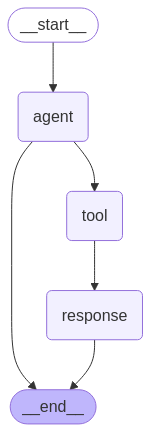

In [27]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        recipe_agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## 10. Creating a User Interface for Our Agent

Let's create a simple function to interact with our agent:

In [28]:
def chat_with_agent(user_input: str, messages: List[Dict[str, str]] = None):
    """Chat with our recipe agent"""
    if messages is None:
        messages = []

    # Initialize the agent state
    state = {"messages": messages, "user_input": user_input, "agent_action": None, "tool_response": None}

    # Run the agent
    result = recipe_agent.invoke(state)

    # Return the updated messages and the last response
    return result["messages"], result["messages"][-1]["content"] if result["messages"] else ""

## 11. Testing Our Agent

Let's test our agent with some example queries:

In [29]:
# Initialize conversation history
conversation = []

# Test 1: Simple greeting
conversation, response = chat_with_agent("Hi there! I'm looking for some cooking help.", conversation)
print("User: Hi there! I'm looking for some cooking help.")
print("Agent:", response)
print("\n" + "-"*50 + "\n")

User: Hi there! I'm looking for some cooking help.
Agent: Hello! I'm here to help you with your cooking. What do you need assistance with today?

--------------------------------------------------



In [30]:
# Test 2: Recipe search
conversation, response = chat_with_agent("I have chicken, broccoli, and rice. What can I make?", conversation)
print("User: I have chicken, broccoli, and rice. What can I make?")
print("Agent:", response)
print("\n" + "-"*50 + "\n")

User: I have chicken, broccoli, and rice. What can I make?
Agent: With chicken, broccoli, and rice, you have the perfect ingredients for a delicious stir-fry! Would you like me to find you a recipe for a chicken, broccoli, and rice stir-fry?

--------------------------------------------------



In [31]:
# Test 3: Creative recipe generation
conversation, response = chat_with_agent("Can you create a fusion recipe that combines Italian and Japanese cuisines?", conversation)
print("User: Can you create a fusion recipe that combines Italian and Japanese cuisines?")
print("Agent:", response)
print("\n" + "-"*50 + "\n")

User: Can you create a fusion recipe that combines Italian and Japanese cuisines?
Agent: That sounds like a fun and creative idea! Let's create a fusion recipe that combines Italian and Japanese cuisines. How about we make a dish called "Sushi Risotto"? It could be a creamy risotto infused with Japanese flavors like soy sauce, mirin, and nori, topped with slices of fresh sashimi-grade fish like tuna or salmon. What do you think of this fusion idea?

--------------------------------------------------



In [32]:
# Test 4: Nutrition information
conversation, response = chat_with_agent("What's the nutritional value of avocados?", conversation)
print("User: What's the nutritional value of avocados?")
print("Agent:", response)
print("\n" + "-"*50 + "\n")

User: What's the nutritional value of avocados?
Agent: Avocados are not only delicious but also packed with nutrients! They are a great source of healthy fats, fiber, vitamins C, E, K, and B-6, as well as folate and potassium. Would you like me to provide more detailed nutrition information about avocados?

--------------------------------------------------



In [21]:
# Test 5: Conversational follow-up
conversation, response = chat_with_agent("Thanks! Can you suggest a healthy breakfast using avocados?", conversation)
print("User: Thanks! Can you suggest a healthy breakfast using avocados?")
print("Agent:", response)
print("\n" + "-"*50 + "\n")

User: Thanks! Can you suggest a healthy breakfast using avocados?
Agent: How about trying an "Avocado Toast with Poached Egg and Cherry Tomatoes"? It's a nutritious and delicious breakfast option that's easy to make. Simply mash some avocado on whole grain toast, top it with a poached egg, and add some halved cherry tomatoes on the side. It's a balanced meal that provides protein, healthy fats, and fiber to start your day off right! Enjoy your breakfast!

--------------------------------------------------



## 12. Interactive Chat Interface

Let's create a simple interactive interface to chat with our agent:

In [22]:
def interactive_chat(visualize=False):
    """Interactive chat with our recipe agent"""
    conversation = []
    print("Welcome to Chef GPT! Type 'exit' to end the conversation or 'visualize' to toggle visualization.")
    print("What cooking questions can I help you with today?")

    while True:
        user_input = input("\nYou: ")
        if user_input.lower() == 'exit':
            print("\nChef GPT: Goodbye! Happy cooking!")
            break
        elif user_input.lower() == 'visualize':
            visualize = not visualize
            print(f"\nVisualization {'enabled' if visualize else 'disabled'}")
            continue

        if visualize:
            result = visualize_agent_execution(user_input, conversation)
            conversation = result["messages"]
        else:
            conversation, response = chat_with_agent(user_input, conversation)
            print(f"\nChef GPT: {response}")

# Uncomment to start an interactive chat
# interactive_chat()

In [23]:
interactive_chat()

Welcome to Chef GPT! Type 'exit' to end the conversation or 'visualize' to toggle visualization.
What cooking questions can I help you with today?

You: hi

Chef GPT: Hello! How can I help you today?

You: generate recipe

Chef GPT: That's exciting! What type of recipe would you like me to generate for you? Do you have any specific preferences or ingredients in mind?

You: meat

Chef GPT: Great choice! Let's create a delicious meat-based recipe. How about we make a savory and comforting Beef Stroganoff? It's a classic dish that's sure to satisfy your taste buds. Would you like me to generate the recipe for Beef Stroganoff for you?

You: ok

Chef GPT: Awesome! Let's get cooking with some Beef Stroganoff. Here's the recipe:

Ingredients:
- 1 lb beef sirloin, thinly sliced
- 1 onion, finely chopped
- 2 cloves garlic, minced
- 8 oz mushrooms, sliced
- 1 cup beef broth
- 1 cup sour cream
- 2 tbsp flour
- 2 tbsp butter
- 1 tbsp olive oil
- Salt and pepper to taste
- Cooked egg noodles, for s

KeyboardInterrupt: Interrupted by user

## 14. Exercises for Students

Now it's your turn to experiment with and extend the agent! Here are some exercises to try:

### Exercise 1: Add a New Tool

Create a new tool that helps the agent convert between different measurement units (e.g., cups to grams, Fahrenheit to Celsius).

In [24]:
# Your code here
@tool
def convert_units(conversion_query: str) -> str:
    """Convert between cooking measurement units (e.g., '2 cups flour to grams', '350F to C')"""
    # Implement your conversion logic here
    # For a simple implementation, you can use the LLM to do the conversion
    prompt = ChatPromptTemplate.from_template(
        "Convert the following cooking measurement: {conversion_query}. Provide only the result with a brief explanation."
    )
    chain = prompt | llm
    response = chain.invoke({"conversion_query": conversion_query})
    return response.content

# Don't forget to update the system prompt to include your new tool!

### Exercise 2: Improve the Agent's Memory

Modify the agent to remember user preferences (like dietary restrictions or favorite ingredients) throughout the conversation.

In [25]:
# Your code here
# Hint: You can extend the AgentState class to include user preferences
class EnhancedAgentState(TypedDict):
    messages: List[Dict[str, str]]
    user_input: str
    agent_action: Optional[Dict[str, Any]]
    tool_response: Optional[str]
    user_preferences: Dict[str, Any]  # Store preferences here

# Then you can create a function to extract preferences from the conversation
def extract_preferences(messages: List[Dict[str, str]], current_preferences: Dict[str, Any]) -> Dict[str, Any]:
    """Extract user preferences from conversation history"""
    # Implement your preference extraction logic here
    # For example, you could use the LLM to analyze the conversation and extract preferences
    return current_preferences  # Return updated preferences

### Exercise 3: Add Error Handling

Improve the agent by adding better error handling for cases where tools fail or the agent's response format is incorrect.

In [26]:
# Your code here
# Hint: You can modify the tool_node function to include try/except blocks
def improved_tool_node(state: AgentState) -> AgentState:
    """Execute the tool with error handling"""
    action = state["agent_action"]

    if not action or not action["tool"]:
        return state

    tool_name = action["tool"]
    tool_input = action["input"]

    try:
        # Execute the appropriate tool
        if tool_name == "search_recipes":
            tool_result = search_recipes(tool_input)
        elif tool_name == "generate_creative_recipe":
            tool_result = generate_creative_recipe(tool_input)
        elif tool_name == "get_nutrition_info":
            tool_result = get_nutrition_info(tool_input)
        else:
            tool_result = f"Error: Unknown tool '{tool_name}'"
    except Exception as e:
        tool_result = f"Error executing {tool_name}: {str(e)}. Please try again with a different query."

    state["tool_response"] = tool_result
    return state

## 15. Conclusion

Congratulations! You've built a functional AI agent that can:

1. Chat with users about food topics
2. Search for recipes based on ingredients
3. Generate creative new recipe ideas
4. Provide nutrition information

### What We've Learned

- How to use LangChain to create chains of LLM operations
- How to create tools that extend an agent's capabilities
- How to use LangGraph to orchestrate agent behavior
- How to maintain conversation state and context
- How to visualize agent workflows and execution

### Next Steps

To further enhance your agent, you could:

1. Connect to real recipe APIs or databases
2. Add image generation for the recipes
3. Implement more sophisticated memory and reasoning
4. Create a web interface for your agent

Happy building!